In [78]:
import pandas as pd

In [79]:
df = pd.read_csv("cleaned_data.csv")
df.head()

,IndexYear,IndexMonth,IndexDayOfWeek,IndexDepartmentKey,IndexDepartmentName,IndexDepartmentType,IndexDepartmentSpecialty,IndexDepartmentCity,IndexDepartmentCounty,IndexDepartmentPostalCode,...,SexualOrientation,SmokingStatus,VitalStatus,ClinicianTitle,PrimaryDepartment,PrimarySpecialty,OfficeCity,OfficePostalCode,isBroken,DistanceMilesToIndexDept
0,2022,1,1,349,901 INTERNAL MED,Missing,Internal Medicine,Topeka,SHAWNEE,66606,...,Straight,Former,Alive,Missing,Missing,Missing,Missing,Missing,0,4.206557
1,2022,1,1,358,901 FAMILY PRACTICE,Missing,Family Medicine,Topeka,SHAWNEE,66606,...,Missing,Never,Alive,Missing,Missing,Missing,Missing,Missing,1,4.693631
2,2022,1,1,10282,ASBURY CLINIC,Missing,Primary Care,TOPEKA,SHAWNEE,66614-4466,...,Straight,Never,Alive,Missing,Missing,Missing,Missing,Missing,0,4.693631
3,2022,1,1,341,823 WOUNDCARE,Missing,Wound Care,Topeka,SHAWNEE,66606,...,Straight,Former,Alive,APRN,823 WOUNDCARE,Nurse Practitioner,TOPEKA,66606,0,2.565065
4,2022,1,1,299,6TH FRAZIER ENDOCRINOLOGY,Missing,Endocrinology,Topeka,SHAWNEE,66606,...,Straight,Never,Alive,Missing,Missing,Missing,Missing,Missing,0,4.693631


In [80]:
df.columns

Index(['IndexYear', 'IndexMonth', 'IndexDayOfWeek', 'IndexDepartmentKey',
       'IndexDepartmentName', 'IndexDepartmentType',
       'IndexDepartmentSpecialty', 'IndexDepartmentCity',
       'IndexDepartmentCounty', 'IndexDepartmentPostalCode',
       'IndexAdmissionSource', 'IndexAdmissionType', 'IndexVisitType',
       'IndexVisitTypeDescription', 'FirstRace', 'MaritalStatus',
       'MyChartStatus', 'OmbEthnicity', 'OmbRace', 'PatientBirthYearBin',
       'SexAssignedAtBirth', 'SexualOrientation', 'SmokingStatus',
       'VitalStatus', 'ClinicianTitle', 'PrimaryDepartment',
       'PrimarySpecialty', 'OfficeCity', 'OfficePostalCode', 'isBroken',
       'DistanceMilesToIndexDept'],
      dtype='object')

In [81]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report

y = df[["isBroken"]]
x = df.drop(columns = ["IndexDepartmentKey","IndexDepartmentPostalCode",
             "PrimaryDepartment","OfficeCity","OfficePostalCode","isBroken"])
x = x.drop(columns = ["PrimarySpecialty","ClinicianTitle","SexualOrientation","SexAssignedAtBirth"
                      ,"IndexAdmissionType","IndexAdmissionSource","IndexDepartmentType"])
x['IndexDepartmentCity'] = x['IndexDepartmentCity'].str.upper()

def clean_visit_type(x):
    if pd.isna(x):
        return "unknown"
    x = x.lower().strip()

    if "clinic" in x and "virtual" in x:
        return "clinic_virtual"
    if "clinic" in x:
        return "clinic_in_person"
    if "lab" in x:
        return "lab"
    if "ultrasound" in x or "imaging" in x:
        return "imaging"
    if "procedure" in x:
        return "procedures"
    if "admission" in x:
        return "pre_admission"

    return "other"

df["IndexVisitTypeDescription"] = df["IndexVisitTypeDescription"].apply(clean_visit_type)
x2 = x.drop(columns = ['IndexDepartmentName'])
y["isBroken"].value_counts(normalize=True)

categorical_cols = x.select_dtypes(include=['object', 'category']).columns
numeric_cols = x.select_dtypes(include=['int64', 'float64']).columns
categorical_cols2 = x2.select_dtypes(include=['object', 'category']).columns
numeric_cols2 = x2.select_dtypes(include=['int64', 'float64']).columns

In [82]:
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


# pipelines
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# combine
preprocessor1 = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])
preprocessor2 = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols2),
    ("cat", categorical_pipeline, categorical_cols2)
])

In [83]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor1),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

pipeline2 = Pipeline(steps=[
    ('preprocessor', preprocessor2),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=4, stratify=y
)
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    x2, y, test_size=0.2, random_state=4, stratify=y
)

In [85]:
pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['IndexYear', 'IndexMonth', 'IndexDayOfWeek', 'PatientBirthYearBin',
       'DistanceMilesToIndexDept'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['IndexDepartmentName', 'IndexDepartmentSpecialty',
       'IndexDepartmentCity', 'IndexDepartmentCounty', 'IndexVisitType',
       'IndexVisitTypeDescription', 'FirstRace', 'MaritalStatus',
       'MyChartStatus', 'OmbEthnicity', 'OmbRace', 'SmokingStatus',
       'VitalStatus'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [86]:
pipeline2.fit(X_train2, y_train2)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['IndexYear', 'IndexMonth', 'IndexDayOfWeek', 'PatientBirthYearBin',
       'DistanceMilesToIndexDept'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['IndexDepartmentSpecialty', 'IndexDepartmentCity',
       'IndexDepartmentCounty', 'IndexVisitType', 'IndexVisitTypeDescription',
       'FirstRace', 'MaritalStatus', 'MyChartStatus', 'OmbEthnicity',
       'OmbRace', 'SmokingStatus', 'VitalStatus'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [87]:
probs = pipeline.predict_proba(X_test)[:, 1]
preds = pipeline.predict(X_test)

print("ROC AUC:", roc_auc_score(y_test, probs))
print(classification_report(y_test, preds))

ROC AUC: 0.7113659323890593
              precision    recall  f1-score   support

           0       0.65      0.57      0.61      1747
           1       0.67      0.74      0.70      2029

    accuracy                           0.66      3776
   macro avg       0.66      0.66      0.66      3776
weighted avg       0.66      0.66      0.66      3776



In [88]:
probs2 = pipeline2.predict_proba(X_test2)[:, 1]
preds2 = pipeline2.predict(X_test2)

print("ROC AUC:", roc_auc_score(y_test2, probs2))
print(classification_report(y_test2, preds2))

ROC AUC: 0.7116614470825577
              precision    recall  f1-score   support

           0       0.65      0.58      0.61      1747
           1       0.67      0.73      0.70      2029

    accuracy                           0.66      3776
   macro avg       0.66      0.65      0.65      3776
weighted avg       0.66      0.66      0.66      3776



In [89]:
# Get feature names after preprocessing
ohe = pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_features = ohe.get_feature_names_out(categorical_cols)

all_features = np.concatenate([encoded_cat_features, numeric_cols])

# Get importances
importances = pipeline.named_steps['model'].feature_importances_

feat_importance = pd.Series(importances, index=all_features)
feat_importance = feat_importance.sort_values(ascending=False)

print(feat_importance.head(20))

IndexDepartmentName_7 NORTH                                 0.135264
IndexDepartmentName_6TH ST MIDTOWN EXPRESS                  0.124102
IndexDepartmentName_6TH FRAZIER ENDOCRINOLOGY               0.119624
IndexDepartmentName_6TH FRAZIER LAB                         0.086666
IndexDepartmentName_6TH FRAZIER DIABETES LEARNING CENTER    0.048559
IndexDepartmentSpecialty_Hematology and Oncology            0.040219
IndexDepartmentName_823 FAMILY PRACTICE                     0.025266
VitalStatus_Deceased                                        0.020444
MaritalStatus_Widowed                                       0.019717
SmokingStatus_Never Assessed                                0.019439
MyChartStatus_Patient Declined                              0.014184
MaritalStatus_Other                                         0.013010
OmbEthnicity_Asked but No Answer                            0.012007
SmokingStatus_Never                                         0.011832
IndexDepartmentSpecialty_Infectiou

In [90]:
# Get feature names after preprocessing
ohe = pipeline2.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_features2 = ohe.get_feature_names_out(categorical_cols2)

all_features = np.concatenate([encoded_cat_features2, numeric_cols2])

# Get importances
importances = pipeline2.named_steps['model'].feature_importances_

feat_importance = pd.Series(importances, index=all_features)
feat_importance = feat_importance.sort_values(ascending=False)

print(feat_importance.head(20))

IndexDepartmentSpecialty_Dermatology                0.146993
IndexDepartmentSpecialty_Cardiothoracic Surgery     0.128076
IndexDepartmentSpecialty_Cardiac Rehabilitation     0.123444
IndexDepartmentSpecialty_Cardiology                 0.089362
IndexDepartmentSpecialty_Bariatrics                 0.049431
IndexDepartmentSpecialty_Hematology and Oncology    0.049035
VitalStatus_Deceased                                0.020376
IndexDepartmentSpecialty_Infectious Diseases        0.019715
MaritalStatus_Widowed                               0.019706
SmokingStatus_Never Assessed                        0.019536
IndexDepartmentSpecialty_Neurology                  0.015595
MyChartStatus_Patient Declined                      0.013804
MaritalStatus_Other                                 0.013363
SmokingStatus_Never                                 0.011983
OmbEthnicity_Asked but No Answer                    0.011961
MyChartStatus_Pending Activation                    0.011647
OmbRace_American Indian 

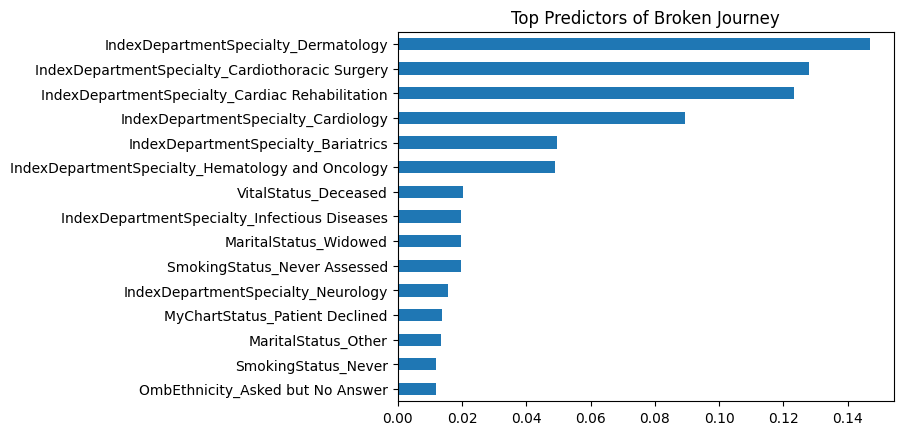

In [91]:
import matplotlib.pyplot as plt

feat_importance.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top Predictors of Broken Journey")
plt.show()

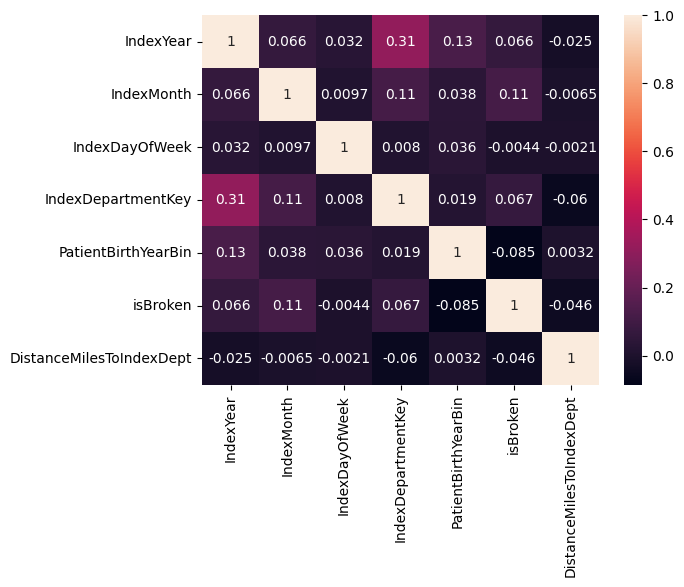

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.show()